In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ive
from math import gamma as math_gamma
import warnings
warnings.filterwarnings('ignore')

# Consistent style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries loaded successfully!")


Libraries loaded successfully!


---
## **1. Definition and SDE**

A **Bessel process** of dimension $\delta > 0$ (also called **index** $\nu = \delta/2 - 1$) starting from $x_0 > 0$ is the unique strong solution to:

$$dX_t = \frac{\delta - 1}{2 X_t} \, dt + dW_t, \quad X_0 = x_0 > 0$$

where $W_t$ is a standard one-dimensional Brownian motion.

### Representation for Integer Dimensions

When $\delta = n \in \{1, 2, 3, \ldots\}$, the Bessel process has an explicit construction. Let $W_t^{(1)}, \ldots, W_t^{(n)}$ be independent standard Brownian motions. Then:

$$X_t = \sqrt{\left(W_t^{(1)}\right)^2 + \cdots + \left(W_t^{(n)}\right)^2}$$

is a Bessel process of dimension $n$.

### Special Cases

| Dimension | Name | Behavior |
|-----------|------|----------|
| $\delta = 1$ | Reflected Brownian motion | $X_t = |W_t|$ |
| $\delta = 2$ | Radial part of planar BM | Never hits 0 (logarithmic) |
| $\delta = 3$ | Bessel-3 process | Related to BM conditioned to stay positive |
| $\delta \geq 2$ | — | Starting from $x_0 > 0$, never hits 0 |

### The Drift Term

The drift $\frac{\delta - 1}{2x}$ is:
- **Repelling** from 0 when $\delta > 1$ (positive drift pushes away)
- **Attracting** to 0 when $\delta < 1$ (negative drift pulls inward)
- **Zero** when $\delta = 1$ (ordinary Brownian motion, reflected at 0)
- 

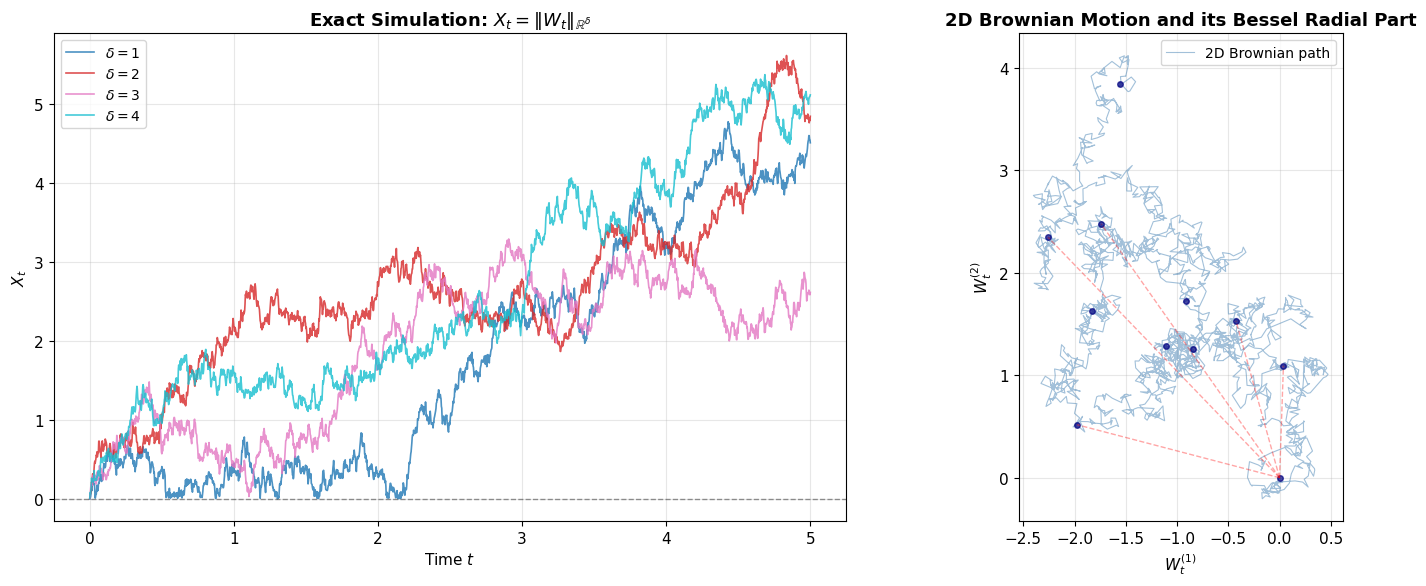

In [43]:
# ============================================================
# 2. Exact Simulation for Integer Dimensions
# ============================================================

np.random.seed(42)

T = 5.0
N = 2000
dt = T / N
t = np.linspace(0, T, N + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Bessel paths for dimensions 1,2,3,4 ---
ax = axes[0]
dims = [1, 2, 3, 4]
colors = plt.cm.tab10(np.linspace(0, 1, len(dims)))

for delta, color in zip(dims, colors):
    dW = np.random.normal(0, np.sqrt(dt), size=(delta, N))
    W = np.concatenate([np.zeros((delta, 1)), np.cumsum(dW, axis=1)], axis=1)
    X = np.sqrt(np.sum(W**2, axis=0))
    ax.plot(t, X, color=color, linewidth=1.2, alpha=0.8, label=rf'$\delta = {delta}$')

ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.4)
ax.set_title(r'Exact Simulation: $X_t = \|W_t\|_{\mathbb{R}^\delta}$', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$X_t$', fontsize=11)
ax.legend(fontsize=10)

# --- Right: 2D Brownian path with radial distances ---
ax = axes[1]
np.random.seed(123)
delta = 2
dW = np.random.normal(0, np.sqrt(dt), size=(delta, N))
W = np.concatenate([np.zeros((delta, 1)), np.cumsum(dW, axis=1)], axis=1)

ax.plot(W[0], W[1], color='steelblue', alpha=0.5, linewidth=0.8, label='2D Brownian path')
ax.plot(W[0, ::200], W[1, ::200], 'o', color='navy', markersize=4, alpha=0.7)

# Draw radial lines at sample times
for idx in [200, 600, 1000, 1400, 1800]:
    ax.plot([0, W[0, idx]], [0, W[1, idx]], 'r--', alpha=0.35, linewidth=1)

ax.set_aspect('equal')
ax.set_title(r'2D Brownian Motion and its Bessel Radial Part', fontsize=13, fontweight='bold')
ax.set_xlabel('$W_t^{(1)}$', fontsize=11)
ax.set_ylabel('$W_t^{(2)}$', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


---
## **3. Hitting Zero and Recurrence**

The behavior at the boundary $x = 0$ is governed entirely by the dimension $\delta$:

- **$\delta \geq 2$:** The process **never hits 0** if started at $x_0 > 0$.
- **$0 < \delta < 2$:** The process hits 0 with probability 1. The boundary is **instantaneously reflecting**.
- **$\delta \leq 0$:** The boundary is **absorbing** (the process sticks at 0).

### Scale and Speed

Using the scale function $s(x) = x^{2-\delta}$:
- If $\delta < 2$, then $s(0) = 0$ is finite and the boundary is accessible.
- If $\delta > 2$, then $s(0) = -\infty$ and 0 is inaccessible.
- If $\delta = 2$, the speed measure is infinite and 0 is inaccessible (but the process approaches 0 arbitrarily closely).
- 

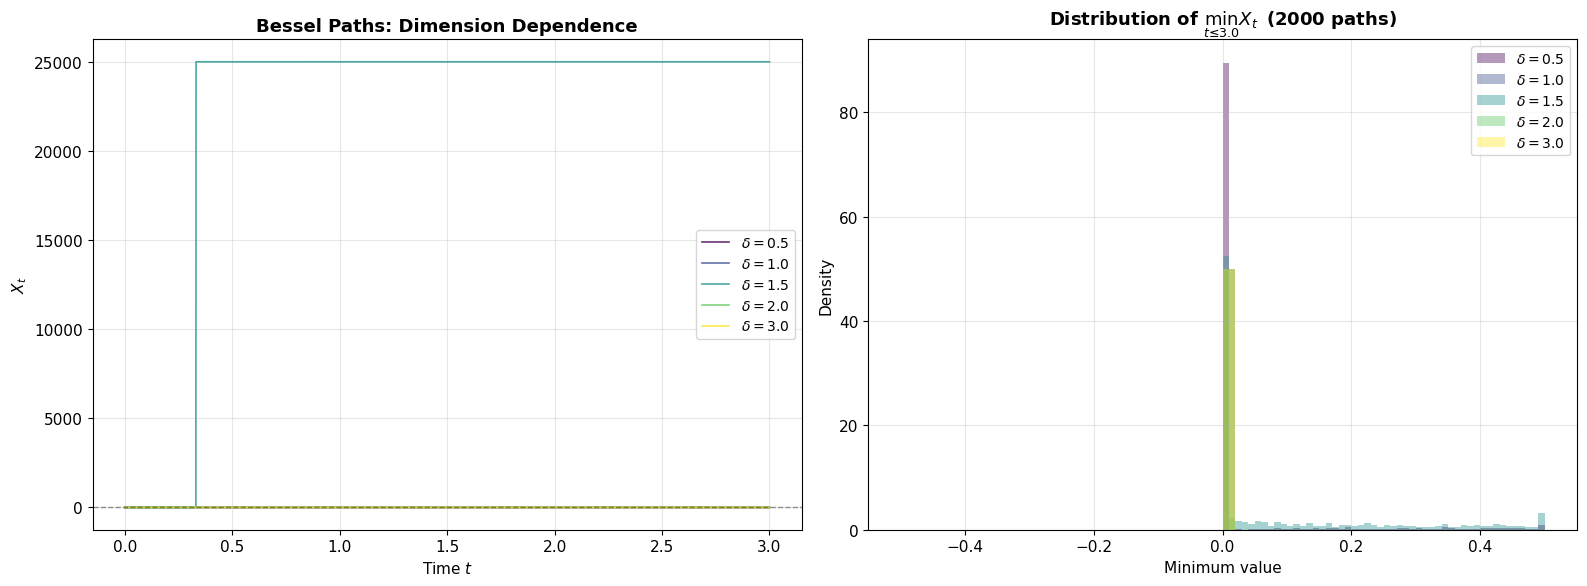

  delta = 0.5: P(min < 1e-3) = 0.894
  delta = 1.0: P(min < 1e-3) = 1.000
  delta = 1.5: P(min < 1e-3) = 0.473
  delta = 2.0: P(min < 1e-3) = 1.000
  delta = 3.0: P(min < 1e-3) = 1.000


In [44]:
# ============================================================
# Hitting Zero: Dimension Dependence
# ============================================================

np.random.seed(55)

def simulate_bessel_path(delta, T, N, x0=0.5):
    """Simulate one Bessel path. Exact for integer delta, Euler otherwise."""
    dt = T / N
    if delta == int(delta) and delta > 0:
        dW = np.random.normal(0, np.sqrt(dt), size=(int(delta), N))
        W = np.concatenate([np.zeros((int(delta), 1)), np.cumsum(dW, axis=1)], axis=1)
        return np.sqrt(np.sum(W**2, axis=0))
    else:
        X = np.zeros(N + 1)
        X[0] = x0
        for i in range(N):
            dW = np.random.normal(0, np.sqrt(dt))
            drift = ((delta - 1.0) / (2.0 * max(X[i], 1e-8))) * dt
            X[i+1] = max(X[i] + drift + dW, 0.0)
        return X


T = 3.0
N = 3000
dt = T / N
t = np.linspace(0, T, N + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: sample paths ---
ax = axes[0]
deltas = [0.5, 1.0, 1.5, 2.0, 3.0]
colors = plt.cm.viridis(np.linspace(0, 1, len(deltas)))

for idx, delta in enumerate(deltas):
    np.random.seed(55 + idx)
    X = simulate_bessel_path(delta, T, N, x0=0.5)
    ax.plot(t, X, color=colors[idx], linewidth=1.2, alpha=0.8, label=rf'$\delta = {delta}$')

ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.4)
ax.set_title('Bessel Paths: Dimension Dependence', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$X_t$', fontsize=11)
ax.legend(fontsize=10)

# --- Right: distribution of minimum values ---
ax = axes[1]
n_sims = 2000
min_vals = {d: [] for d in deltas}

for delta in deltas:
    for sim in range(n_sims):
        seed_val = 1000 + int(delta * 100) + sim
        np.random.seed(seed_val)
        X = simulate_bessel_path(delta, T, N, x0=0.5)
        min_vals[delta].append(np.min(X))

for idx, delta in enumerate(deltas):
    ax.hist(min_vals[delta], bins=50, density=True, alpha=0.4, color=colors[idx],
            label=rf'$\delta = {delta}$')

ax.set_title(rf'Distribution of $\min_{{t \leq {T}}} X_t$ ({n_sims} paths)', fontsize=13, fontweight='bold')
ax.set_xlabel('Minimum value', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Print hitting statistics
for delta in deltas:
    hit_rate = np.mean(np.array(min_vals[delta]) < 1e-3)
    print(rf"  delta = {delta}: P(min < 1e-3) = {hit_rate:.3f}")


---
## **4. Transition Density**

For $x_0 > 0$ and $y > 0$, the transition density of the Bessel process of dimension $\delta$ is:

$$p_t(x_0, y) = \frac{y}{t} \left(\frac{y}{x_0}\right)^{\nu} \exp\!\left(-\frac{x_0^2 + y^2}{2t}\right) I_{\nu}\!\left(\frac{x_0 y}{t}\right)$$

where $\nu = \frac{\delta}{2} - 1$ and $I_{\nu}$ is the **modified Bessel function of the first kind**.

For numerical stability, we rewrite using the exponentially scaled function $I_{\nu}^{\text{exp}}(z) = I_{\nu}(z) e^{-z}$:

$$p_t(x_0, y) = \frac{y}{t} \left(\frac{y}{x_0}\right)^{\nu} \exp\!\left(-\frac{(x_0 - y)^2}{2t}\right) I_{\nu}^{\text{exp}}\!\left(\frac{x_0 y}{t}\right)$$

### Starting from the Origin

If $x_0 = 0$ and $\delta > 0$:

$$p_t(0, y) = \frac{2}{t^{\delta/2} \, \Gamma(\delta/2)} \, y^{\delta - 1} \exp\!\left(-\frac{y^2}{2t}\right)$$

This is a **generalized Gamma distribution** (also known as a Nakagami distribution).


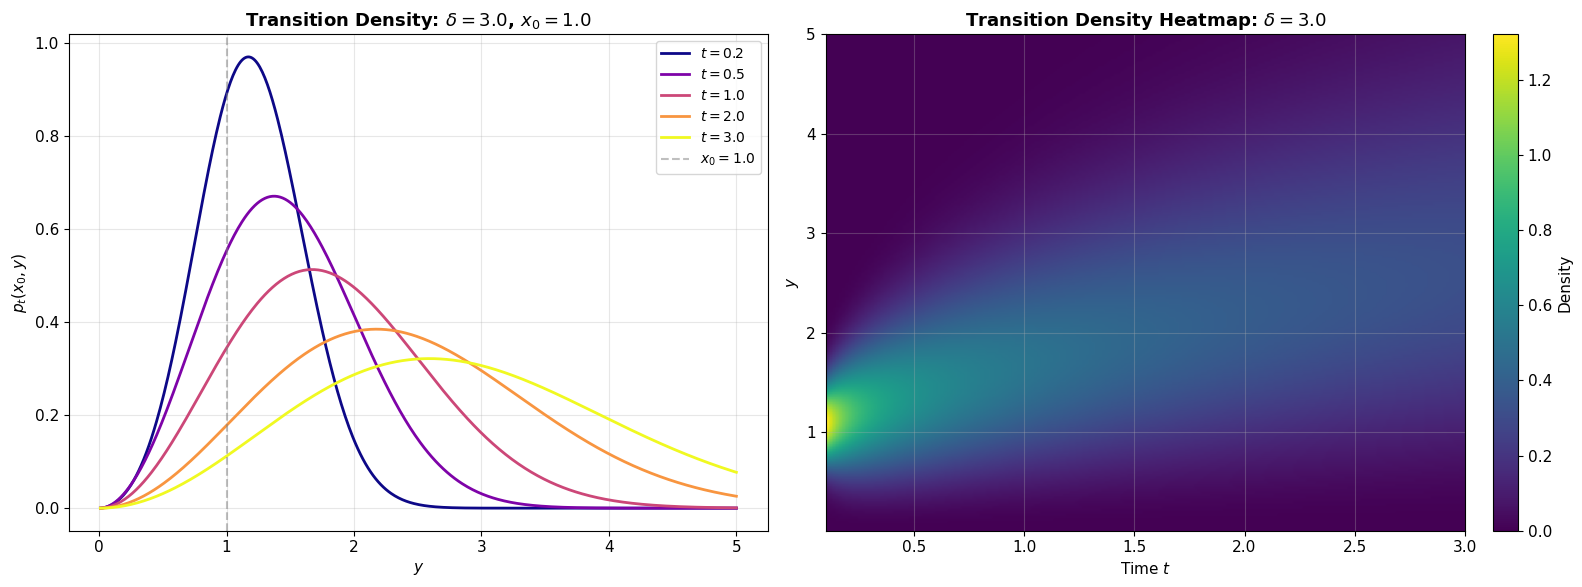

In [45]:
# ============================================================
# Transition Density: Lines and Heatmap
# ============================================================

def bessel_density(y, t, x0, delta):
    """Vectorized transition density using exponentially scaled Bessel."""
    nu = delta / 2.0 - 1.0
    y = np.asarray(y, dtype=float)
    y_safe = np.maximum(y, 1e-10)
    
    if x0 <= 1e-10:
        C = (2.0 / (t**(delta / 2.0) * math_gamma(delta / 2.0))) * np.exp(-y_safe**2 / (2.0 * t))
        return C * (y_safe**(delta - 1.0))
    else:
        ratio = y_safe / x0
        arg = x0 * y_safe / t
        I_nu_scaled = ive(nu, arg)  # ive(nu, z) = iv(nu, z) * exp(-z) for real z > 0
        prefactor = (y_safe / t) * (ratio**nu)
        return prefactor * np.exp(-(x0 - y_safe)**2 / (2.0 * t)) * I_nu_scaled


np.random.seed(7)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: density slices at fixed times ---
ax = axes[0]
delta = 3.0
x0 = 1.0
y_grid = np.linspace(0.01, 5.0, 500)
t_values = [0.2, 0.5, 1.0, 2.0, 3.0]
colors = plt.cm.plasma(np.linspace(0, 1, len(t_values)))

for t_val, color in zip(t_values, colors):
    p = bessel_density(y_grid, t_val, x0, delta)
    ax.plot(y_grid, p, color=color, linewidth=2, label=rf'$t = {t_val}$')

ax.axvline(x=x0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, label=rf'$x_0 = {x0}$')
ax.set_title(rf'Transition Density: $\delta = {delta}$, $x_0 = {x0}$', fontsize=13, fontweight='bold')
ax.set_xlabel('$y$', fontsize=11)
ax.set_ylabel('$p_t(x_0, y)$', fontsize=11)
ax.legend(fontsize=10)

# --- Right: heatmap p_t(x0, y) over (t, y) ---
ax = axes[1]
delta = 3.0
x0 = 1.0
t_grid = np.linspace(0.1, 3.0, 200)
y_grid = np.linspace(0.01, 5.0, 200)
T_mesh, Y_mesh = np.meshgrid(t_grid, y_grid)

P = bessel_density(Y_mesh, T_mesh, x0, delta)

im = ax.imshow(P, aspect='auto', origin='lower',
               extent=[t_grid[0], t_grid[-1], y_grid[0], y_grid[-1]],
               cmap='viridis', vmin=0)
ax.set_title(rf'Transition Density Heatmap: $\delta = {delta}$', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$y$', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Density')

plt.tight_layout()
plt.show()


---
## **5. Euler-Maruyama for General Dimension**

For non-integer $\delta$, we cannot simulate via the norm of independent Brownian motions. Instead, we use the **Euler-Maruyama scheme** on the SDE:

$$X_{t+\Delta t} = \max\!\left( X_t + \frac{\delta - 1}{2 X_t} \Delta t + \Delta W_t, \; 0 \right)$$

The $\max(\cdot, 0)$ enforces a **reflecting boundary** at 0, which is appropriate for $\delta > 0$.

### Accuracy Note

The Euler-Maruyama scheme introduces a discretization bias of order $O(\sqrt{\Delta t})$ for the strong error. Near 0, the drift singularity requires small time steps for stability.


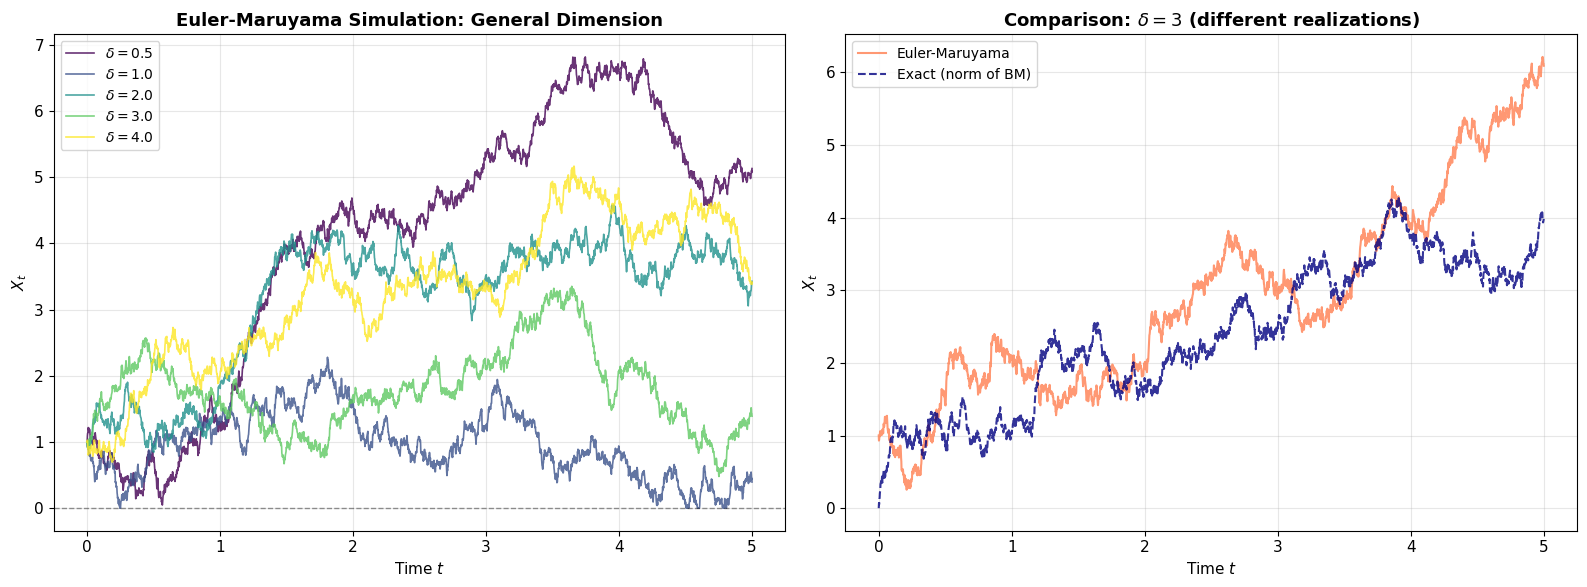

In [46]:
# ============================================================
# Euler-Maruyama Simulation
# ============================================================

np.random.seed(88)

def simulate_bessel_euler(delta, x0, T, N):
    dt = T / N
    t = np.linspace(0, T, N + 1)
    X = np.zeros(N + 1)
    X[0] = x0
    for i in range(N):
        dW = np.random.normal(0, np.sqrt(dt))
        drift = ((delta - 1.0) / (2.0 * max(X[i], 1e-8))) * dt
        X[i+1] = max(X[i] + drift + dW, 0.0)
    return t, X


T = 5.0
N = 3000
x0 = 1.0

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Euler paths for various delta ---
ax = axes[0]
deltas = [0.5, 1.0, 2.0, 3.0, 4.0]
colors = plt.cm.viridis(np.linspace(0, 1, len(deltas)))

for idx, delta in enumerate(deltas):
    np.random.seed(88 + idx)
    t, X = simulate_bessel_euler(delta, x0, T, N)
    ax.plot(t, X, color=colors[idx], linewidth=1.2, alpha=0.8, label=rf'$\delta = {delta}$')

ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.4)
ax.set_title('Euler-Maruyama Simulation: General Dimension', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$X_t$', fontsize=11)
ax.legend(fontsize=10)

# --- Right: typical exact vs Euler path for delta = 3 ---
ax = axes[1]
delta = 3

np.random.seed(100)
t_e, X_e = simulate_bessel_euler(delta, x0, T, N)

np.random.seed(200)
dt = T / N
dW = np.random.normal(0, np.sqrt(dt), size=(delta, N))
W = np.concatenate([np.zeros((delta, 1)), np.cumsum(dW, axis=1)], axis=1)
X_exact = np.sqrt(np.sum(W**2, axis=0))

ax.plot(t_e, X_e, color='coral', linewidth=1.5, alpha=0.8, label='Euler-Maruyama')
ax.plot(t_e, X_exact, color='navy', linewidth=1.5, alpha=0.8, linestyle='--', label='Exact (norm of BM)')
ax.set_title(rf'Comparison: $\delta = {delta}$ (different realizations)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$X_t$', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


---
## **6. Squared Bessel Process and CIR**

The **squared Bessel process** $Z_t = X_t^2$ satisfies the SDE:

$$dZ_t = \delta \, dt + 2 \sqrt{Z_t} \, dW_t$$

This is the prototype for the **Cox-Ingersoll-Ross (CIR)** interest rate model:

$$dr_t = a(b - r_t) \, dt + \sigma \sqrt{r_t} \, dW_t$$

Indeed, a time-changed, scaled squared Bessel process is equivalent to the CIR process. The condition $\delta > 0$ ensures that $Z_t$ (and hence $X_t$) remains non-negative.

### Simulation of the Squared Process

We simulate $Z_t$ directly and then compare $X_t = \sqrt{Z_t}$ with a directly simulated Bessel path.


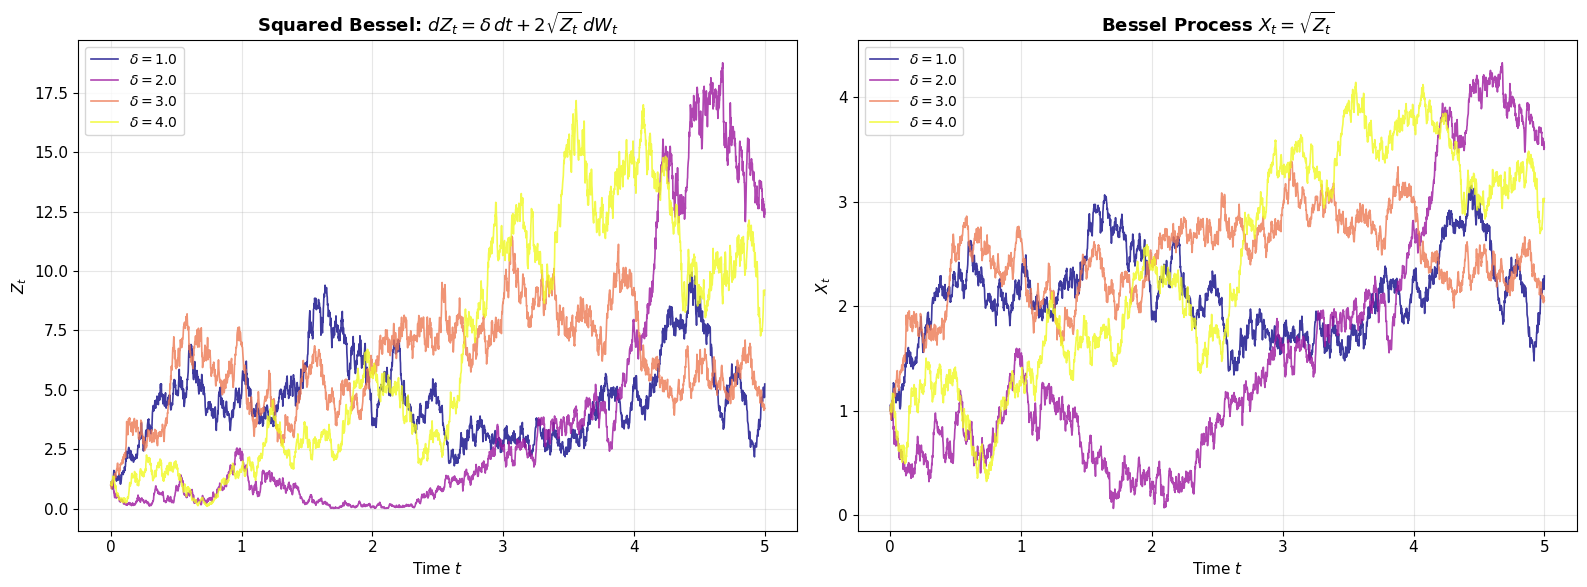

In [47]:
# ============================================================
# Squared Bessel Process Simulation
# ============================================================

np.random.seed(66)

def simulate_squared_bessel(delta, x0, T, N):
    dt = T / N
    t = np.linspace(0, T, N + 1)
    Z = np.zeros(N + 1)
    Z[0] = x0**2
    for i in range(N):
        dW = np.random.normal(0, np.sqrt(dt))
        Z[i+1] = max(Z[i] + delta * dt + 2.0 * np.sqrt(max(Z[i], 0.0)) * dW, 0.0)
    return t, Z


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: squared Bessel paths ---
ax = axes[0]
deltas = [1.0, 2.0, 3.0, 4.0]
colors = plt.cm.plasma(np.linspace(0, 1, len(deltas)))

for idx, delta in enumerate(deltas):
    np.random.seed(66 + idx)
    t, Z = simulate_squared_bessel(delta, 1.0, 5.0, 3000)
    ax.plot(t, Z, color=colors[idx], linewidth=1.2, alpha=0.8, label=rf'$\delta = {delta}$')

ax.set_title(r'Squared Bessel: $dZ_t = \delta \, dt + 2\sqrt{Z_t} \, dW_t$', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$Z_t$', fontsize=11)
ax.legend(fontsize=10)

# --- Right: corresponding Bessel paths (square root) ---
ax = axes[1]
for idx, delta in enumerate(deltas):
    np.random.seed(66 + idx)
    t, Z = simulate_squared_bessel(delta, 1.0, 5.0, 3000)
    ax.plot(t, np.sqrt(Z), color=colors[idx], linewidth=1.2, alpha=0.8, label=rf'$\delta = {delta}$')

ax.set_title(r'Bessel Process $X_t = \sqrt{Z_t}$', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$X_t$', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


---
## **7. Summary**

| Property | Formula / Behavior |
|----------|-------------------|
| **SDE** | $dX_t = \frac{\delta - 1}{2 X_t} dt + dW_t$ |
| **Integer representation** | $X_t = \|W_t\|_{\mathbb{R}^\delta}$ |
| **Hitting 0** | Never if $\delta \geq 2$; hits if $0 < \delta < 2$ |
| **Transition density** | $p_t(x_0, y) = \frac{y}{t} (\frac{y}{x_0})^\nu e^{-(x_0-y)^2/(2t)} I_\nu^{\text{exp}}(\frac{x_0 y}{t})$ |
| **Squared process** | $dZ_t = \delta dt + 2\sqrt{Z_t} dW_t$ |
| **CIR connection** | Time-changed squared Bessel |

### References

1. **Revuz, D. & Yor, M.** (1999). *Continuous Martingales and Brownian Motion* (3rd ed.). Springer.
2. **Karatzas, I. & Shreve, S.E.** (1991). *Brownian Motion and Stochastic Calculus* (2nd ed.). Springer.
3. **Going-Jaeschke, A. & Yor, M.** (2003). "A survey and some generalizations of Bessel processes." *Bernoulli*, 9(2), 313-349.
4. **Cox, J.C., Ingersoll, J.E. & Ross, S.A.** (1985). "A Theory of the Term Structure of Interest Rates." *Econometrica*, 53(2), 385-407.


